# Código del Libro

In [9]:
from random import random, randint, sample
from collections import namedtuple
import matplotlib.pyplot as plt

In [10]:
# Calcula el capital invertido por un individuo
def capitalInvertido(individuo):
    return sum(map(lambda x,y: x*y.precio, individuo, inversiones))

# Calcula el rendimiento obtenido por un individuo
def rendimiento(individuo):
    return sum(map(lambda x,y: x*y.precio*y.rendim,
                              individuo, inversiones))


# Si un individuo gasta más capital del disponible, se eliminan
# aleatoriamente inversiones hasta que se ajusta al capital
def ajustaCapital(individuo):
    ajustado = individuo[:]
    while capitalInvertido(ajustado)>capital:
        pos = randint(0, len(ajustado)-1)
        if ajustado[pos] > 0:
            ajustado[pos] -= 1

    return ajustado


# Crea un individuo al azar, en este caso una selección de
# inversiones que no excedan el capital disponible
def creaIndividuo(inversiones, capital):
    individuo = [0]*len(inversiones)

    while capitalInvertido(individuo) < capital:
        eleccion = randint(0, len(inversiones)-1)
        individuo[eleccion] += 1

    return ajustaCapital(individuo)


# Crea un nuevo individuo cruzando otros dos (cuyas posiciones se
# indican en el segundo parámetro)
def cruza(poblacion, posiciones):
    L = len(poblacion[0])

    # Toma los genes del primer progenitor y luego toma al azar
    # un segmento de entre 1 y L genes del segundo progenitor
    hijo   = poblacion[posiciones[0]][:]
    inicio = randint(0, L-1)
    fin    = randint(inicio+1, L)
    hijo[inicio:fin] = poblacion[posiciones[1]][inicio:fin]

    return ajustaCapital(hijo)


# Aplica mutaciones a un individuo según una tasa dada; garantiza
# que cumple las restricciones de capital e inversiones
def muta(individuo, tasaMutacion):
    mutado = []
    for i in range(len(individuo)):
        if random() > tasaMutacion:
            mutado.append(individuo[i])
        else:
            mutado.append(randint(0, inversiones[i].cantidad))

    return ajustaCapital(mutado)


# Hace evolucionar el sistema durante un número de generaciones
def evoluciona(poblacion, generaciones):

    # Ordena la población inicial por rendimiento producido
    poblacion.sort(key=lambda x: rendimiento(x))

    # Algunos valores útiles
    N = len(poblacion)
    tasaMutacion = 0.01

    # Genera una lista del tipo [0,1,1,2,2,3,3,3,3,...] para
    # representar las probabilidades de reproducirse de cada
    # individuo (el primero 1 posibilidad, el segundo 2, etc.)
    reproduccion = [x for x in range(N) for y in range(x+1)]

    for i in range(generaciones):
        # Se generan N-1 nuevos individuos cruzando los existentes
        # (sin que se repitan los padres)
        padres = sample(reproduccion, 2)
        while padres[0]==padres[1]:
            padres = sample(reproduccion, 2)
        hijos = [cruza(poblacion, padres) for x in range(N-1)]

        # Se aplican mutaciones con una cierta probabilidad
        hijos = [muta(x, tasaMutacion) for x in hijos]

        # Se añade el mejor individuo de la población anterior
        # (elitismo)
        hijos.append(poblacion[-1])
        poblacion = hijos

        # Se ordenan los individuos por rendimiento
        poblacion.sort(key=lambda x: rendimiento(x))


    # Devuelve el mejor individuo encontrado
    return poblacion[-1]


# Declara una tupla con nombres para representar cada inversión
Inversion = namedtuple('Inversion', 'precio cantidad rendim')

numInver  = 100
maxPrecio = 1000
maxCant   = 10
maxRend   = 0.2


# Genera una lista de tuplas Inversion
inversiones=[Inversion(random()*maxPrecio, randint(1, maxCant),
                       random()*maxRend) for i in range(numInver)]
print(inversiones)

# Este cambio lo realicé siendo que no me encanta el print.
# Así aqui presento una mejor manera de mostrar las inversiones
for i, inv in enumerate(inversiones):
    print(
        f"Bono {i:>3} | Precio: ${inv.precio:>8.2f} | Cantidad: {inv.cantidad:>2} | Rendimiento: {inv.rendim:.4f}"
    )
individuos   = 20
generaciones = 1000

poblacion = [creaIndividuo(inversiones, capital)
                           for i in range(individuos)]

# Nota: para simplificar el programa se accede a inversiones y
# capital de forma global (sólo se leen, no se modifican)

mejor = evoluciona(poblacion, generaciones)
print(mejor, capitalInvertido(mejor), rendimiento(mejor))

[Inversion(precio=85.48475620688345, cantidad=4, rendim=0.12089011330148365), Inversion(precio=437.3102348596122, cantidad=5, rendim=0.02911805700172028), Inversion(precio=97.91876548829792, cantidad=7, rendim=0.018435247169442805), Inversion(precio=615.5057039755422, cantidad=4, rendim=0.00546410411965197), Inversion(precio=226.98518969664727, cantidad=10, rendim=0.1809238510223811), Inversion(precio=931.003599295107, cantidad=5, rendim=0.00657062713854586), Inversion(precio=256.160341865574, cantidad=6, rendim=0.11416455854300155), Inversion(precio=708.8287168486402, cantidad=9, rendim=0.18077828640758364), Inversion(precio=217.6720887301241, cantidad=7, rendim=0.08060561375944514), Inversion(precio=93.48300915604901, cantidad=6, rendim=0.1720672580453968), Inversion(precio=667.5739942630452, cantidad=3, rendim=0.09056182544931723), Inversion(precio=228.65050779142183, cantidad=3, rendim=0.17099117035121925), Inversion(precio=385.2243558730007, cantidad=7, rendim=0.13398603664551845)

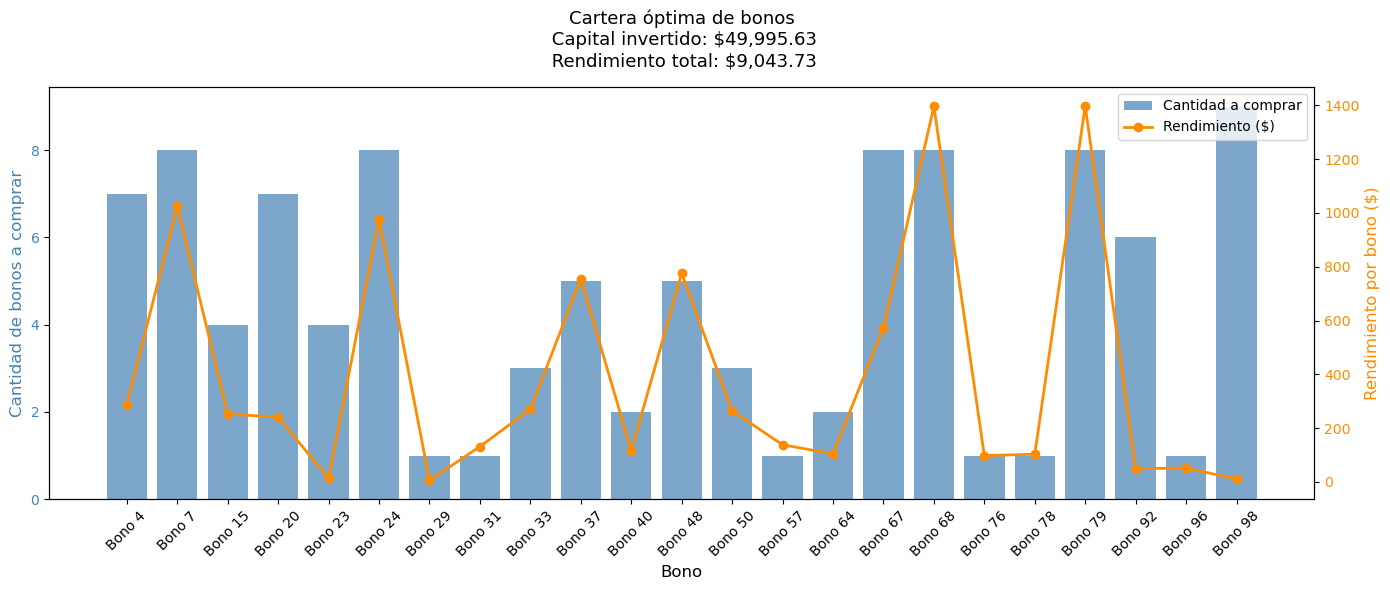

In [11]:
indices_activos = [i for i, cant in enumerate(mejor) if cant > 0]
cantidades = [mejor[i] for i in indices_activos]
rendimientos_ind = [
    mejor[i] * inversiones[i].precio * inversiones[i].rendim for i in indices_activos
]
etiquetas = [f"Bono {i}" for i in indices_activos]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras de cantidad de bonos a comprar
color_barras = "steelblue"
barras = ax1.bar(
    etiquetas, cantidades, color=color_barras, alpha=0.7, label="Cantidad a comprar"
)
ax1.set_xlabel("Bono", fontsize=12)
ax1.set_ylabel("Cantidad de bonos a comprar", color=color_barras, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_barras)
ax1.tick_params(axis="x", rotation=45)

# Eje secundario donde se muestra el rendimiento individual de cada bono
ax2 = ax1.twinx()
ax2.plot(
    etiquetas,
    rendimientos_ind,
    color="darkorange",
    marker="o",
    linewidth=2,
    markersize=6,
    label="Rendimiento ($)",
)
ax2.set_ylabel("Rendimiento por bono ($)", color="darkorange", fontsize=12)
ax2.tick_params(axis="y", labelcolor="darkorange")

# Título e información general
plt.title(
    f"Cartera óptima de bonos"
    f"\n Capital invertido: ${capitalInvertido(mejor):,.2f}"
    f"\n Rendimiento total: ${rendimiento(mejor):,.2f}",
    fontsize=13,
    pad=15,
)

lineas1, etiq1 = ax1.get_legend_handles_labels()
lineas2, etiq2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiq1 + etiq2, loc="upper right")

fig.tight_layout()
plt.savefig("cartera_optima_bonos.png", dpi=150)
plt.show()

# Código Modificado con Librería Deep

In [12]:
from random import random, randint
from collections import namedtuple
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

In [13]:
Inversion = namedtuple("Inversion", "precio cantidad rendim")

numInver = 100
maxPrecio = 1000
maxCant = 10
maxRend = 0.2

inversiones = [
    Inversion(random() * maxPrecio, randint(1, maxCant), random() * maxRend)
    for i in range(numInver)
]

capital = 50000
individuos = 20
generaciones = 1000

def capitalInvertido(individuo):
    return sum(x * y.precio for x, y in zip(individuo, inversiones))


def ajustaCapital(individuo):
    while capitalInvertido(individuo) > capital:
        pos = randint(0, len(individuo) - 1)
        if individuo[pos] > 0:
            individuo[pos] -= 1
    return individuo

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("gene", randint, 0, maxCant)
toolbox.register(
    "individual", tools.initRepeat, creator.Individual, toolbox.gene, n=numInver
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluar(individuo):
    if capitalInvertido(individuo) > capital:
        return (0.0,)
    rendim = sum(x * y.precio * y.rendim for x, y in zip(individuo, inversiones))
    return (rendim,)


toolbox.register("evaluate", evaluar)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register(
    "mutate",
    tools.mutUniformInt,
    low=0,
    up=[inv.cantidad for inv in inversiones],
    indpb=0.01,
)

toolbox.register("select", tools.selTournament, tournsize=3)

poblacion = toolbox.population(n=individuos)

# Monitorea la evolución con estadísticas
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", max)
stats.register("avg", lambda x: sum(v[0] for v in x) / len(x))

hof = tools.HallOfFame(1)  # Mejor individuo encontrado

poblacion, log = algorithms.eaSimple(
    poblacion,
    toolbox,
    cxpb=0.7,  # probabilidad de cruce
    mutpb=0.2,  # probabilidad de mutación
    ngen=generaciones,
    stats=stats,
    halloffame=hof,
    verbose=True,
)

# RESULTADO

mejor = ajustaCapital(hof[0])
print("\nMejor individuo:", mejor)
print(f"Capital invertido: ${capitalInvertido(mejor):,.2f}")
print(
    f"Rendimiento total: ${sum(x * y.precio * y.rendim for x, y in zip(mejor, inversiones)):,.2f}"
)

c:\Users\panch\anaconda3\envs\notebook\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\panch\anaconda3\envs\notebook\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	max   	avg
0  	20    	(0.0,)	0  
1  	15    	(0.0,)	0  
2  	16    	(0.0,)	0  
3  	16    	(0.0,)	0  
4  	13    	(0.0,)	0  
5  	12    	(0.0,)	0  
6  	13    	(0.0,)	0  
7  	12    	(0.0,)	0  
8  	15    	(0.0,)	0  
9  	18    	(0.0,)	0  
10 	17    	(0.0,)	0  
11 	17    	(0.0,)	0  
12 	18    	(0.0,)	0  
13 	16    	(0.0,)	0  
14 	12    	(0.0,)	0  
15 	17    	(0.0,)	0  
16 	15    	(0.0,)	0  
17 	14    	(0.0,)	0  
18 	10    	(0.0,)	0  
19 	14    	(0.0,)	0  
20 	10    	(0.0,)	0  
21 	16    	(0.0,)	0  
22 	18    	(0.0,)	0  
23 	20    	(0.0,)	0  
24 	15    	(0.0,)	0  
25 	17    	(0.0,)	0  
26 	15    	(0.0,)	0  
27 	9     	(0.0,)	0  
28 	16    	(0.0,)	0  
29 	14    	(0.0,)	0  
30 	12    	(0.0,)	0  
31 	12    	(0.0,)	0  
32 	16    	(0.0,)	0  
33 	16    	(0.0,)	0  
34 	15    	(0.0,)	0  
35 	12    	(0.0,)	0  
36 	16    	(0.0,)	0  
37 	14    	(0.0,)	0  
38 	16    	(0.0,)	0  
39 	11    	(0.0,)	0  
40 	20    	(0.0,)	0  
41 	17    	(0.0,)	0  
42 	12    	(0.0,)	0  
43 	14    	(0.0,)	0  
44 	14    

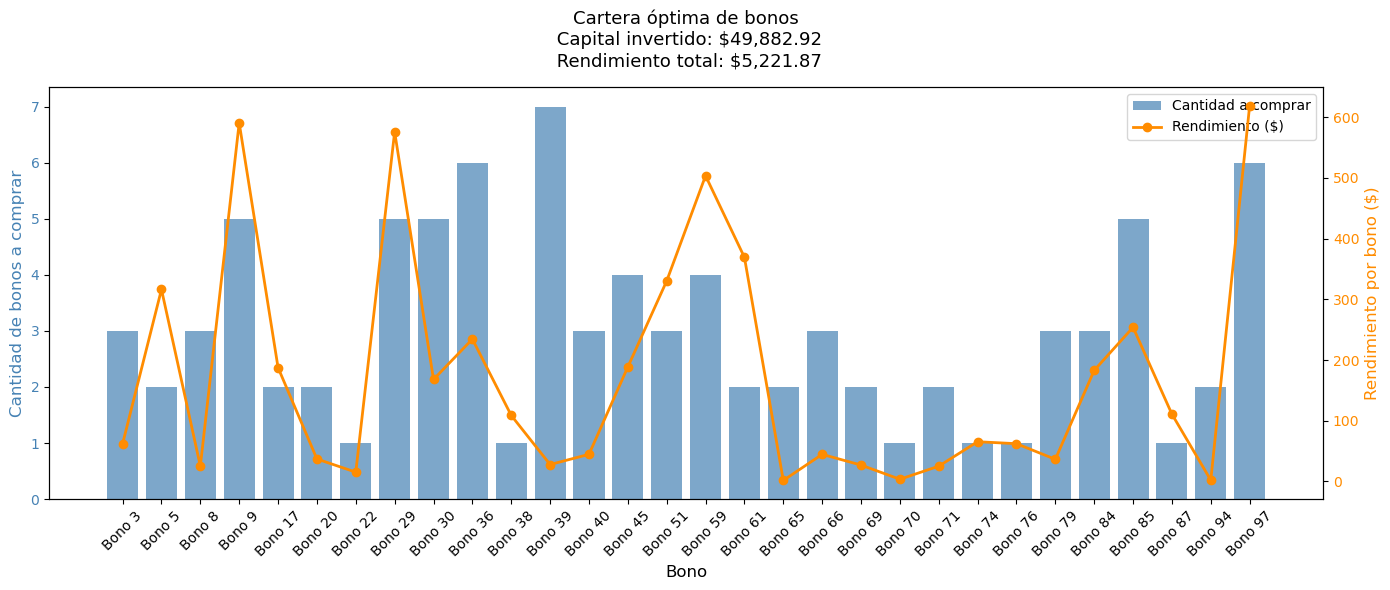

In [14]:
indices_activos = [i for i, cant in enumerate(mejor) if cant > 0]
cantidades = [mejor[i] for i in indices_activos]
rendimientos_ind = [
    mejor[i] * inversiones[i].precio * inversiones[i].rendim for i in indices_activos
]
etiquetas = [f"Bono {i}" for i in indices_activos]

fig, ax1 = plt.subplots(figsize=(14, 6))

color_barras = "steelblue"
ax1.bar(
    etiquetas, cantidades, color=color_barras, alpha=0.7, label="Cantidad a comprar"
)
ax1.set_xlabel("Bono", fontsize=12)
ax1.set_ylabel("Cantidad de bonos a comprar", color=color_barras, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_barras)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    etiquetas,
    rendimientos_ind,
    color="darkorange",
    marker="o",
    linewidth=2,
    markersize=6,
    label="Rendimiento ($)",
)
ax2.set_ylabel("Rendimiento por bono ($)", color="darkorange", fontsize=12)
ax2.tick_params(axis="y", labelcolor="darkorange")

# Título e información general
plt.title(
    f"Cartera óptima de bonos"
    f"\n Capital invertido: ${capitalInvertido(mejor):,.2f}"
    f"\n Rendimiento total: ${sum(x * y.precio * y.rendim for x, y in zip(mejor, inversiones)):,.2f}",
    fontsize=13,
    pad=15,
)

lineas1, etiq1 = ax1.get_legend_handles_labels()
lineas2, etiq2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiq1 + etiq2, loc="upper right")

fig.tight_layout()
plt.savefig("cartera_optima_bonos_deap.png", dpi=150)
plt.show()

# Análisis Comparativo

## 1. Diferencias en la Función Objetivo

En el algoritmo manual, la función **rendimiento(individuo)** retorna un valor escalar float y
delega la validación del capital a **ajustaCapital()**, garantizando que todos los individuos sean
válidos antes de evaluarse. En DEAP, la función **evaluar(individuo)** retorna obligatoriamente una
tupla (float,) e incorpora la verificación del capital internamente, penalizando con (0.0,)
si el individuo supera el presupuesto.

## 2. Diferencias en la Programación del Fitness

El algoritmo manual no tiene un objeto formal de fitness, siendo que simplemente ordena la población por
rendimiento y toma el último elemento como el mejor, aplicando el elitismo de forma manual. Por otro lado, DEAP
formaliza esto con **creator.create("FitnessMax", weights=(1.0,))**, donde el peso positivo indica
maximización, y gestiona el elitismo automáticamente mediante **tools.HallOfFame(1)**.

## 3. Diferencias en los Operadores de Selección, Cruza y Mutación

La **selección** manual usa una ruleta ponderada que favorece proporcionalmente a los mejores
individuos, mientras que DEAP usa selección por torneo, introduciendo más aleatoriedad. En la
**cruza**, el manual intercambia un segmento de longitud variable entre dos padres, mientras que
DEAP aplica **cxTwoPoint**, un cruce de dos puntos fijos. La **mutación** en ambos casos reemplaza
genes aleatoriamente dentro del rango permitido, pero DEAP lo gestiona de forma vectorizada con
**mutUniformInt**, controlando la probabilidad tanto a nivel de individuo como de gen.

## 4. Resultados Obtenidos

### Algoritmo Genético Manual
- **Capital invertido:** $49,995.63
- **Rendimiento total:** $9,043.73
- **Bonos seleccionados:** 23 bonos activos

### DEAP
- **Capital invertido:** $49,882.92
- **Rendimiento total:** $5,221.87
- **Bonos seleccionados:** 34 bonos activos

### Conclusión

El algoritmo manual obtuvo un rendimiento 73% mayor que DEAP ($9,043 vs $5,221). Esto se debe
a que su selección por ruleta ejerce mayor presión hacia los mejores individuos y garantiza
soluciones válidas en todo momento con **ajustaCapital()**. Sin embargo, DEAP exploró más bonos (34 vs 23)
pero con menor rendimiento total, priorizando diversidad sobre concentración.